  Selecione os 3 arquivos CSV quando a janela abrir...


Saving Tabela_Docente_2025.csv to Tabela_Docente_2025 (1).csv
Saving Tabela_Escola_2025.csv to Tabela_Escola_2025 (1).csv
Saving Tabela_Matricula_2025.csv to Tabela_Matricula_2025 (1).csv

  Arquivos recebidos: ['Tabela_Docente_2025 (1).csv', 'Tabela_Escola_2025 (1).csv', 'Tabela_Matricula_2025 (1).csv']

  PROJETO A3 — ETL + DASHBOARD + EDA
  Censo Escolar 2025 — INEP

[1/6] Carregando arquivos...
  ✓ Encontrado: Tabela_Escola_2025 (1).csv
  ✓ Encontrado: Tabela_Docente_2025 (1).csv
  ✓ Encontrado: Tabela_Matricula_2025 (1).csv
  ✓ Escola:    214,192 linhas | 302 colunas
  ✓ Docente:   178,772 linhas | 156 colunas
  ✓ Matrícula: 178,766 linhas | 237 colunas

[2/6] Padronizando e limpando...
  Escola:    214,192 → 214,192 linhas
  Docente:   178,772 → 178,772 linhas
  Matrícula: 178,766 → 178,766 linhas

[3/6] Transformando dados...
  Nulos nas colunas binárias: 33,652 por coluna → preenchidos com 0
  ✓ Base consolidada: 214,192 escolas | 16 colunas
  ✓ Indicadores criados: aluno_por_p

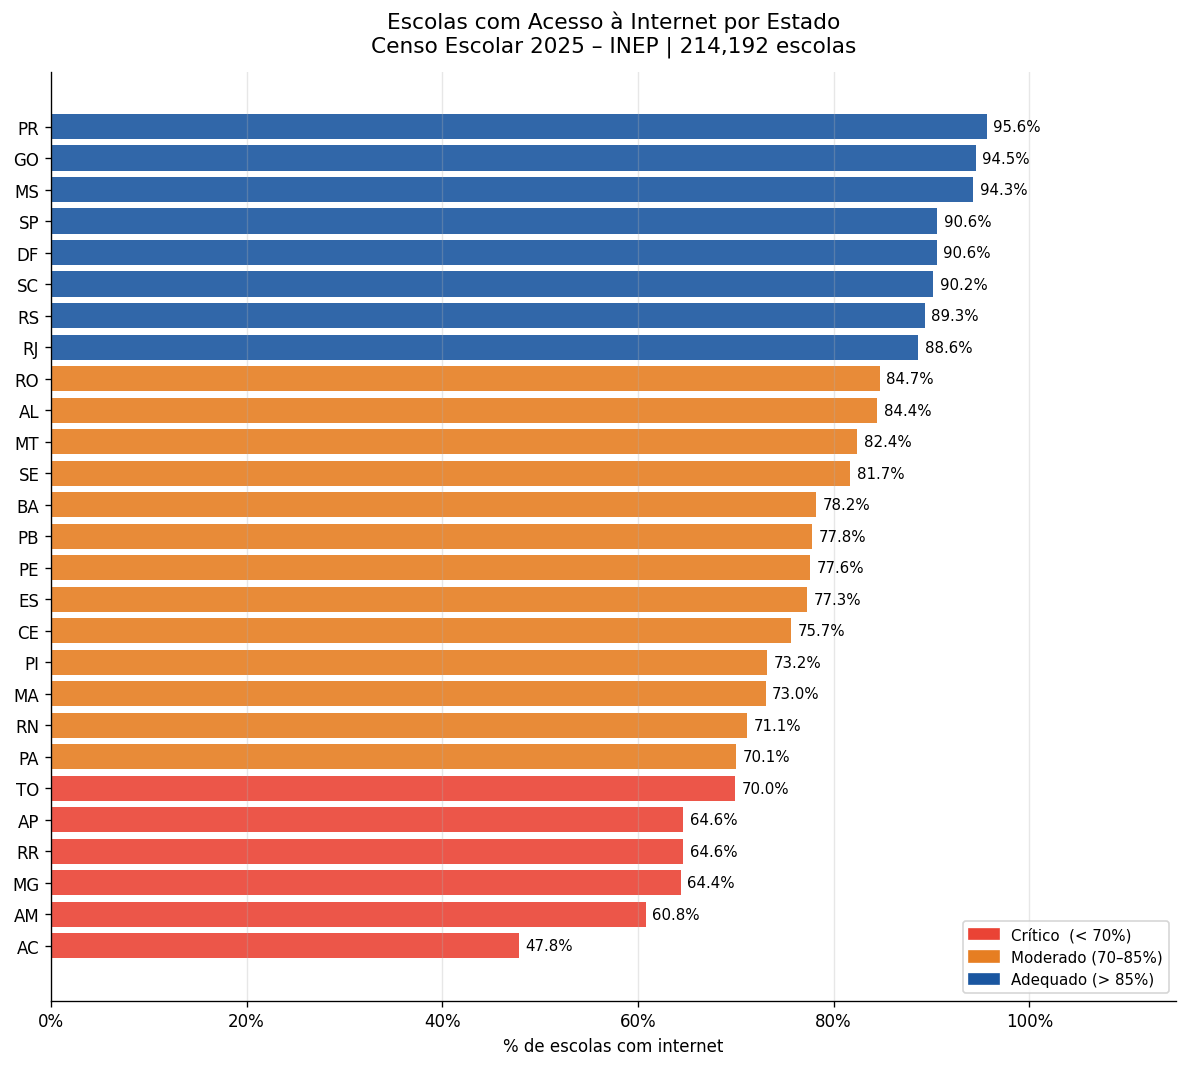

  ✓ G1 — Pior: AC (47.8%) | Melhor: PR (95.6%)


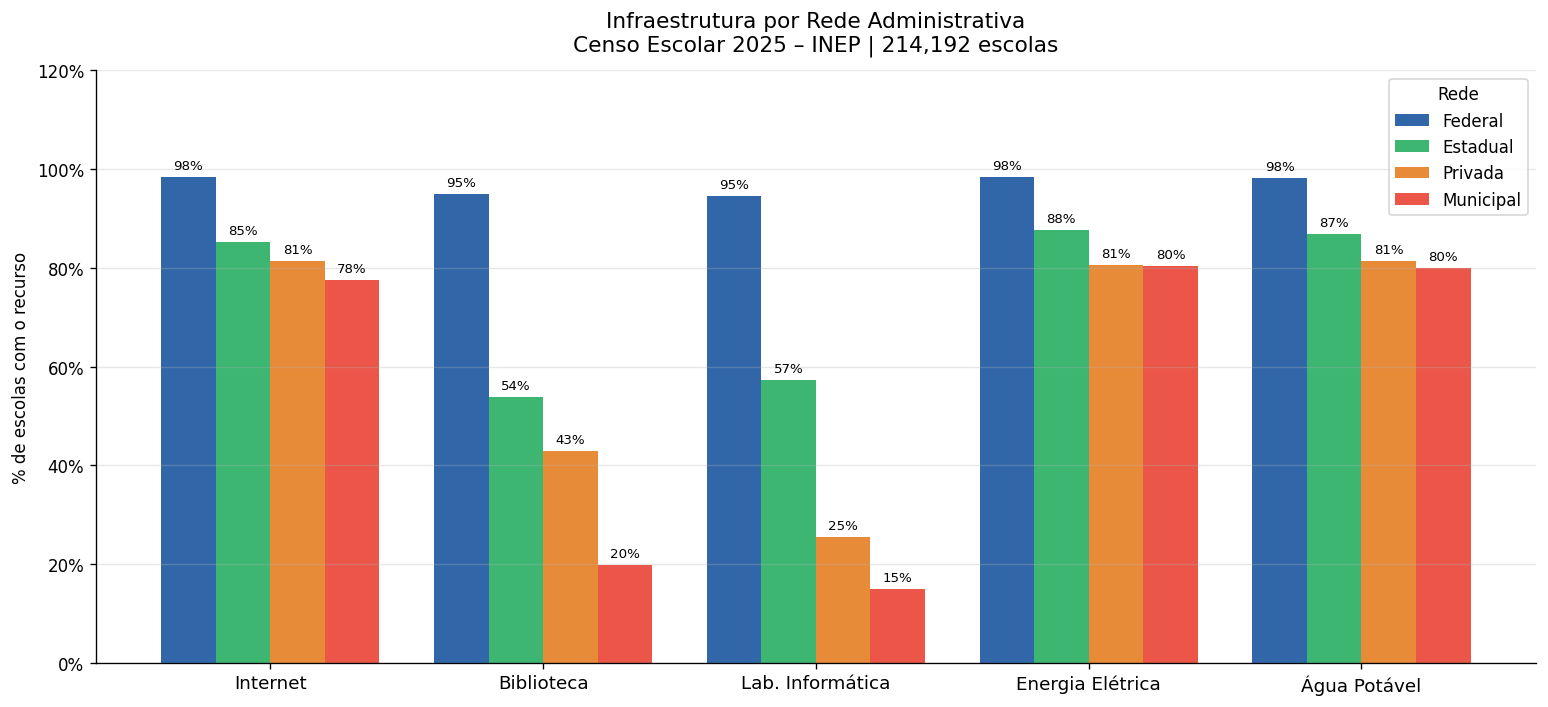

  ✓ G2 — Infraestrutura por rede


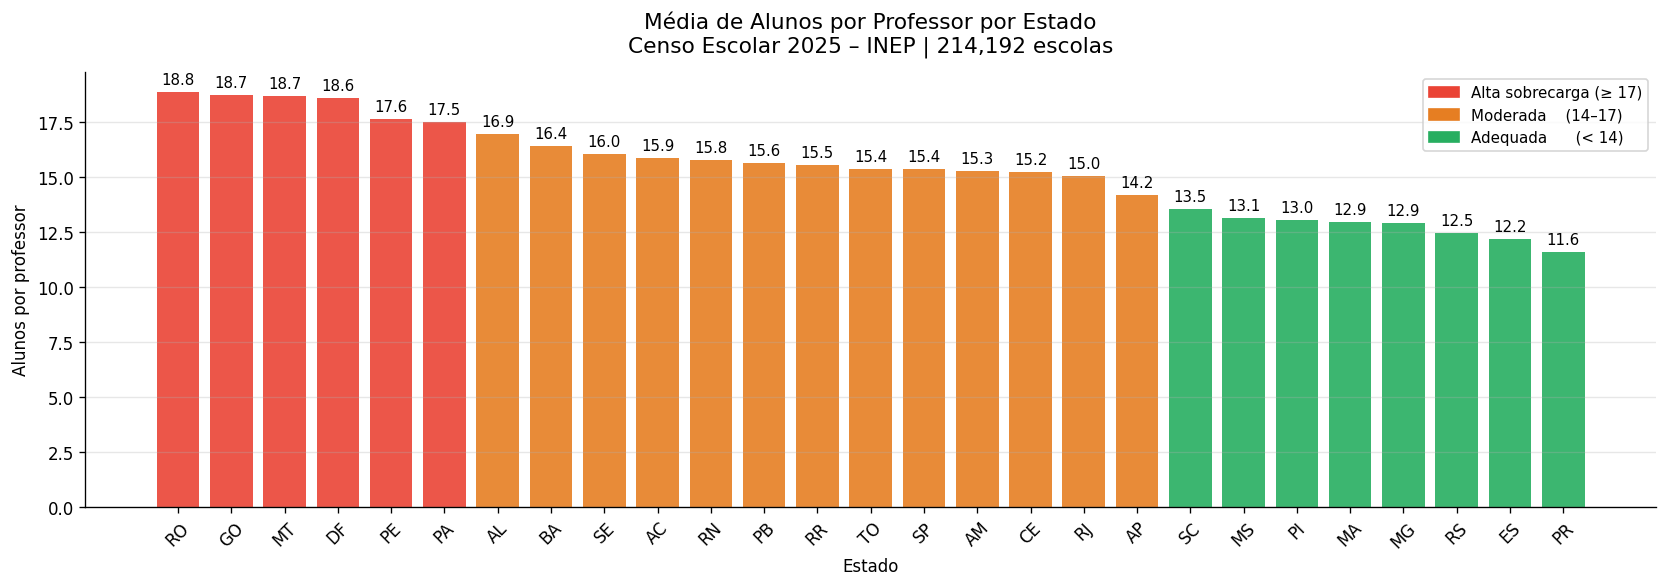

  ✓ G3 — Maior: RO (18.8) | Menor: PR (11.6)


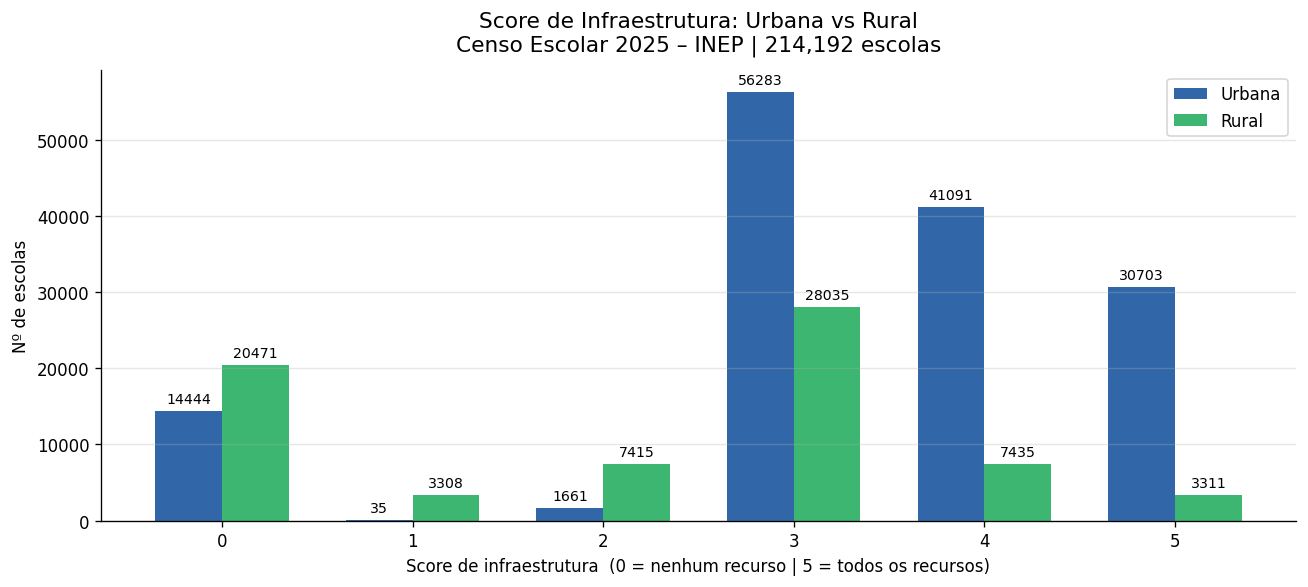

  ✓ G4 — Score Urbana vs Rural


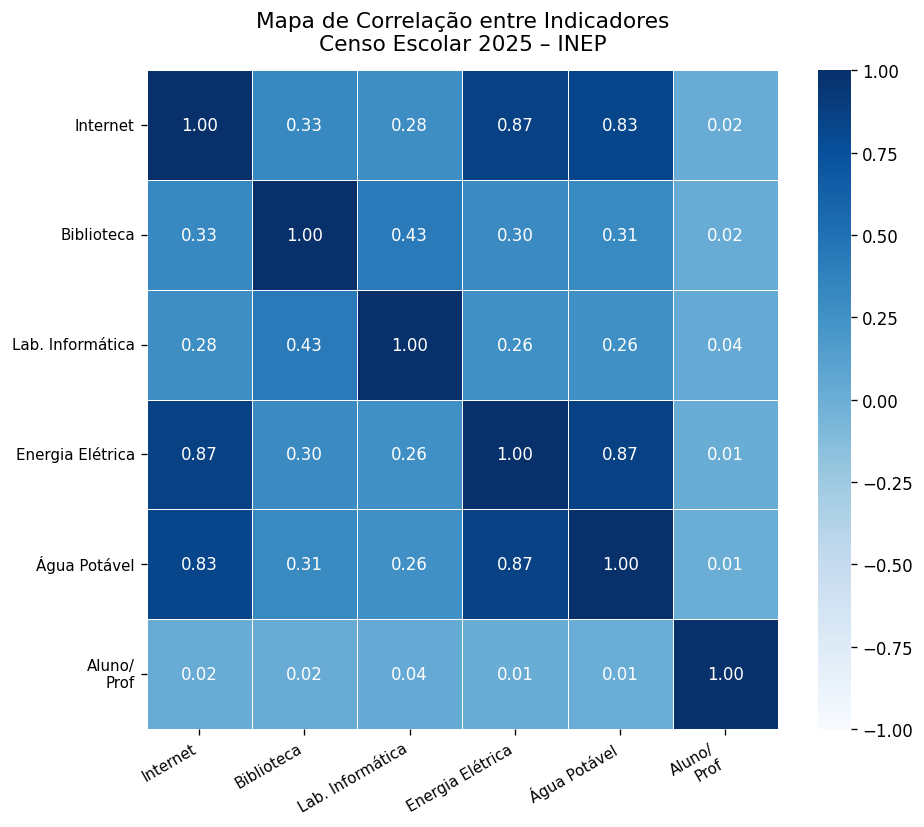

  ✓ G5 — Mapa de correlação


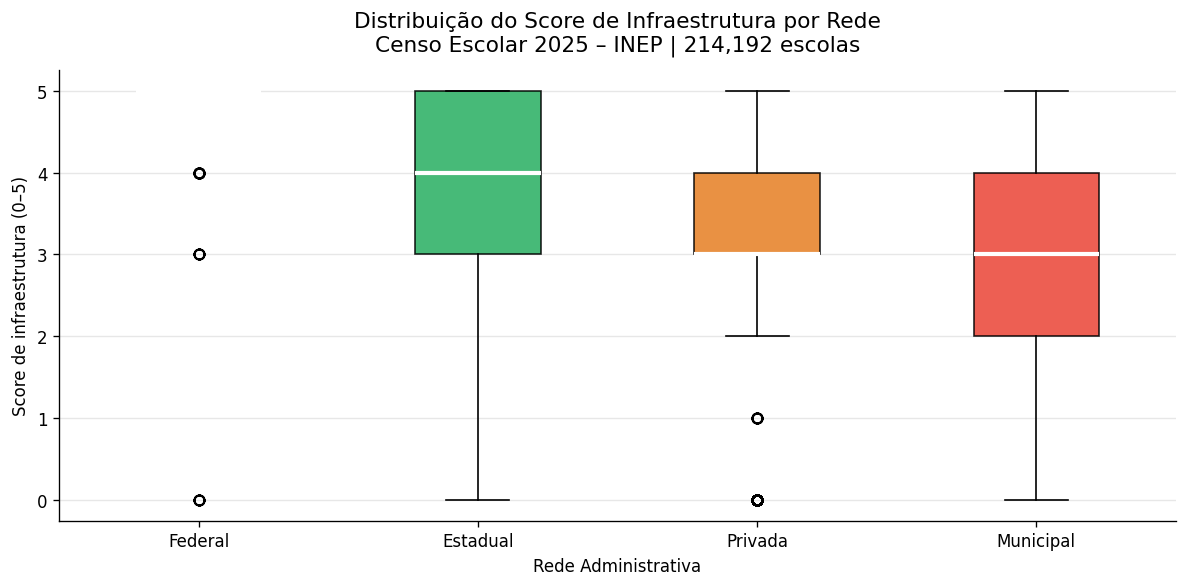

  ✓ G6 — Boxplot por rede


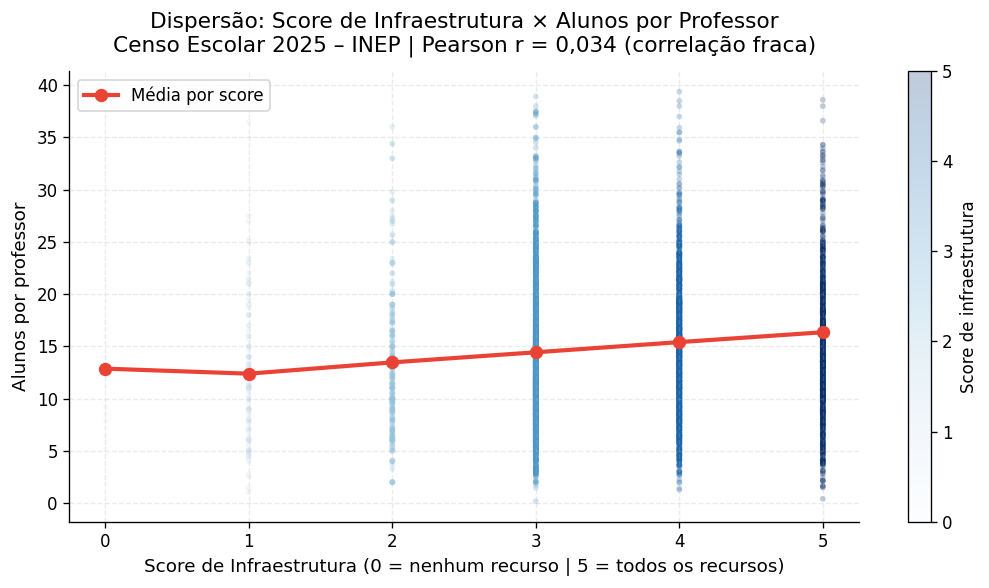

  ✓ G7 — Gráfico de dispersão (score × aluno/prof)
    Pearson r = 0.0342


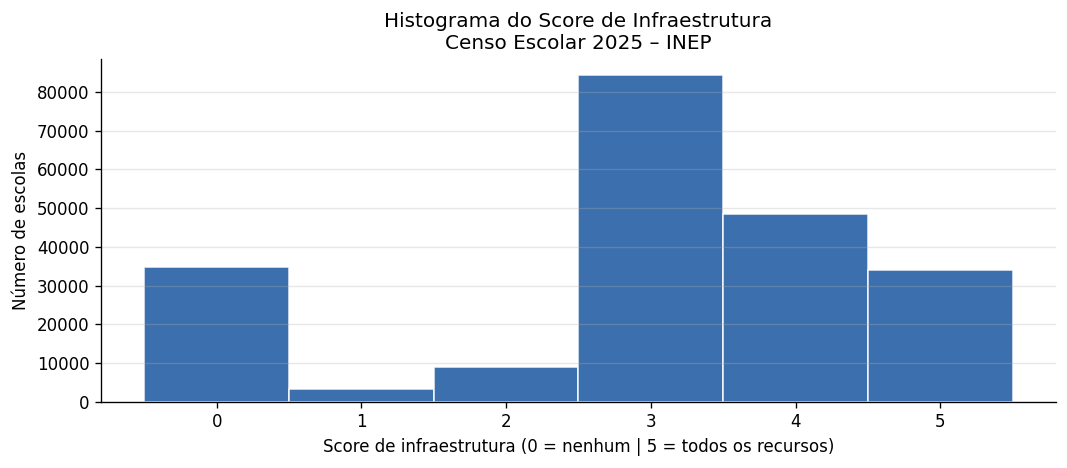


  ETAPA 7 — DASHBOARD INTERATIVO (Plotly)


  ✓ DASHBOARD_COMPLETO_A3.html salvo!

  INSIGHTS IDENTIFICADOS (dados reais)

  📶 INTERNET:
     Pior:    AC → 47.8%
     Melhor:  PR  → 95.6%
     Gap:     47.8 p.p.
     Críticos (<70%): AC, AM, MG, RR, AP, TO

  🏫 INFRAESTRUTURA:
     Score médio geral: 2.98 / 5.0
     Federal   : 96.9%
     Estadual  : 74.1%
     Privada   : 62.3%
     Municipal : 54.5%

  👨‍🏫 SOBRECARGA DOCENTE:
     Maior: RO → 18.8 alunos/prof
     Menor: PR → 11.6 alunos/prof
     Alta sobrecarga (≥17): RO, GO, MT, DF, PE, PA

  🌆 URBANA vs RURAL:
     Rurais sem nenhum recurso (score 0):    20,471
     Urbanas com todos os recursos (score 5): 30,703
     Rurais com todos os recursos (score 5):  3,311

  PROJETO FINALIZADO COM SUCESSO! 🚀

  Arquivos gerados:
    base_final.csv
    g1_internet_estado.png
    g2_infra_rede.png
    g3_aluno_professor.png
    g4_urbana_rural.png
    g5_correlacao.png
    g6_boxplot_rede.png
    g7_dispersao.png         ← gráfico de dispersão (novo)
    DASHBOARD_COMPLETO_A3.html


In [4]:
# =========================================================
# PROJETO A3 — ETL + DASHBOARD + EDA
# UC: ANÁLISE DE DADOS E BIG DATA — UNIFACS 2026/1
# Tema: Educação — Censo Escolar 2025 (INEP)
#
# INSTRUÇÕES:
# 1. Baixe os arquivos:
#    → Tabela_Escola_2025.csv
#    → Tabela_Docente_2025.csv
#    → Tabela_Matricula_2025.csv
# 2. Execute — uma janela de upload vai aparecer
# 3. Selecione os 3 arquivos CSV ao mesmo tempo:
#    → Tabela_Escola_2025.csv
#    → Tabela_Docente_2025.csv
#    → Tabela_Matricula_2025.csv
# =========================================================

# ── Instalar bibliotecas ─────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'plotly', '-q'])

# ── UPLOAD DOS ARQUIVOS  ────────────
from google.colab import files
print("=" * 62)
print("  Selecione os 3 arquivos CSV quando a janela abrir...")
print("=" * 62)
uploaded = files.upload()   # ← aqui é definida a variável 'uploaded'
print(f"\n  Arquivos recebidos: {list(uploaded.keys())}")

# ── Importar bibliotecas ─────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import io, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("\n" + "=" * 62)
print("  PROJETO A3 — ETL + DASHBOARD + EDA")
print("  Censo Escolar 2025 — INEP")
print("=" * 62)

# =========================================================
# ETAPA 1 — CARREGAR OS 3 ARQUIVOS
# =========================================================
print("\n[1/6] Carregando arquivos...")

def carregar(nome_base):
    """
    Carrega CSV pelo nome, tolerando sufixos (1), (2) do Colab.
    """
    for k in uploaded.keys():
        nome_limpo = (k.lower()
                       .replace(' (1)', '').replace(' (2)', '').replace(' (3)', '')
                       .strip())
        if nome_base.lower() == nome_limpo:
            print(f"  ✓ Encontrado: {k}")
            return pd.read_csv(
                io.BytesIO(uploaded[k]),
                sep=';', encoding='latin1', low_memory=False
            )
    raise FileNotFoundError(
        f"\n  ✗ Arquivo '{nome_base}' não encontrado.\n"
        f"  Arquivos disponíveis: {list(uploaded.keys())}\n"
        f"  Dica: verifique se o nome do arquivo está exatamente correto."
    )

escola    = carregar('Tabela_Escola_2025.csv')
docente   = carregar('Tabela_Docente_2025.csv')
matricula = carregar('Tabela_Matricula_2025.csv')

orig_escola    = len(escola)
orig_docente   = len(docente)
orig_matricula = len(matricula)

print(f"  ✓ Escola:    {orig_escola:,} linhas | {escola.shape[1]} colunas")
print(f"  ✓ Docente:   {orig_docente:,} linhas | {docente.shape[1]} colunas")
print(f"  ✓ Matrícula: {orig_matricula:,} linhas | {matricula.shape[1]} colunas")

# =========================================================
# ETAPA 2 — PADRONIZAR E LIMPAR
# =========================================================
print("\n[2/6] Padronizando e limpando...")

escola.columns    = escola.columns.str.lower().str.strip()
docente.columns   = docente.columns.str.lower().str.strip()
matricula.columns = matricula.columns.str.lower().str.strip()

escola    = escola.dropna(how='all').drop_duplicates()
docente   = docente.dropna(how='all').drop_duplicates()
matricula = matricula.dropna(how='all').drop_duplicates()

print(f"  Escola:    {orig_escola:,} → {len(escola):,} linhas")
print(f"  Docente:   {orig_docente:,} → {len(docente):,} linhas")
print(f"  Matrícula: {orig_matricula:,} → {len(matricula):,} linhas")

# =========================================================
# ETAPA 3 — TRANSFORMAÇÃO
# =========================================================
print("\n[3/6] Transformando dados...")

cols_binarias = [
    'in_internet', 'in_biblioteca',
    'in_laboratorio_informatica',
    'in_energia_rede_publica', 'in_agua_potavel'
]
cols_binarias = [c for c in cols_binarias if c in escola.columns]

escola_limpa = escola[[
    'co_entidade', 'no_uf', 'sg_uf', 'no_municipio',
    'tp_dependencia', 'tp_localizacao'
] + cols_binarias].copy()

# Nulos → 0 (metodologia INEP: ausência = recurso inexistente)
nulos = escola_limpa[cols_binarias].isnull().sum()
print(f"  Nulos nas colunas binárias: {nulos.max():,} por coluna → preenchidos com 0")
escola_limpa[cols_binarias] = escola_limpa[cols_binarias].fillna(0)

# Traduzir códigos numéricos para labels legíveis
escola_limpa['tp_dependencia'] = escola_limpa['tp_dependencia'].replace(
    {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'})
escola_limpa['tp_localizacao'] = escola_limpa['tp_localizacao'].replace(
    {1: 'Urbana', 2: 'Rural'})

# Agregar por escola ANTES do merge (evita duplicação de linhas)
mat_agg = (matricula.groupby('co_entidade', as_index=False)
           .agg(qt_mat_bas=('qt_mat_bas', 'sum')))
doc_agg = (docente.groupby('co_entidade', as_index=False)
           .agg(qt_doc_bas=('qt_doc_bas', 'sum')))

# Merge LEFT JOIN via co_entidade
base = (escola_limpa
        .merge(mat_agg, on='co_entidade', how='left')
        .merge(doc_agg,  on='co_entidade', how='left'))

base['qt_mat_bas'] = base['qt_mat_bas'].fillna(0)
base['qt_doc_bas'] = base['qt_doc_bas'].fillna(0)

# Novos indicadores analíticos
base['aluno_por_professor'] = np.where(
    base['qt_doc_bas'] > 0,
    (base['qt_mat_bas'] / base['qt_doc_bas']).round(2),
    np.nan   # NaN = sem docente registrado (não zero)
)
base['score_infra'] = base[cols_binarias].sum(axis=1)
base['porte_escola'] = pd.cut(
    base['qt_mat_bas'],
    bins=[-1, 0, 100, 500, 1000, float('inf')],
    labels=['Sem registro', 'Pequena (≤100)', 'Média (101-500)',
            'Grande (501-1000)', 'Muito grande (>1000)']
)

print(f"  ✓ Base consolidada: {len(base):,} escolas | {base.shape[1]} colunas")
print(f"  ✓ Indicadores criados: aluno_por_professor | score_infra | porte_escola")

# =========================================================
# ETAPA 4 — EXPORTAR BASE FINAL
# =========================================================
print("\n[4/6] Exportando base_final.csv...")
base.to_csv('base_final.csv', index=False, encoding='utf-8')
print("  ✓ base_final.csv salvo! (use para o dashboard e relatório)")

# =========================================================
# ETAPA 5 — ESTATÍSTICAS DESCRITIVAS (EDA)
# =========================================================
print("\n" + "=" * 62)
print("  ETAPA 5 — ESTATÍSTICAS DESCRITIVAS")
print("=" * 62)

total        = len(base)
pct_internet = base['in_internet'].mean() * 100
pct_bib      = base['in_biblioteca'].mean() * 100
pct_lab      = base['in_laboratorio_informatica'].mean() * 100
pct_energia  = base['in_energia_rede_publica'].mean() * 100
pct_agua     = base['in_agua_potavel'].mean() * 100
media_ap     = base['aluno_por_professor'].mean()
score_med    = base['score_infra'].mean()

print(f"\n  Total de escolas analisadas    : {total:,}")
print(f"  % com acesso à internet        : {pct_internet:.1f}%")
print(f"  % com biblioteca               : {pct_bib:.1f}%")
print(f"  % com laboratório informática  : {pct_lab:.1f}%")
print(f"  % com energia elétrica         : {pct_energia:.1f}%")
print(f"  % com água potável             : {pct_agua:.1f}%")
print(f"  Média de alunos por professor  : {media_ap:.1f}")
print(f"  Score médio de infraestrutura  : {score_med:.2f} / 5.0")

print("\n  --- Distribuição por rede administrativa ---")
print(base['tp_dependencia'].value_counts().to_string())

print("\n  --- Distribuição por localização ---")
print(base['tp_localizacao'].value_counts().to_string())

print("\n  --- Estatísticas completas: aluno por professor ---")
print(base['aluno_por_professor'].describe().round(2).to_string())

print("\n  --- Estatísticas completas: score de infraestrutura (0–5) ---")
print(base['score_infra'].describe().round(2).to_string())

# =========================================================
# ETAPA 6 — GRÁFICOS ESTÁTICOS (7 gráficos)
# =========================================================
print("\n" + "=" * 62)
print("  ETAPA 6 — GRÁFICOS ESTÁTICOS")
print("=" * 62)

LABELS = {
    'in_internet':                'Internet',
    'in_biblioteca':              'Biblioteca',
    'in_laboratorio_informatica': 'Lab. Informática',
    'in_energia_rede_publica':    'Energia Elétrica',
    'in_agua_potavel':            'Água Potável'
}
AZUL     = '#1A56A0'
VERMELHO = '#EA4335'
VERDE    = '#27AE60'
LARANJA  = '#E67E22'

# ── GRÁFICO 1: Internet por Estado ────────────────────────
internet_uf = (base.groupby('sg_uf')['in_internet']
               .mean().mul(100).sort_values())
fig, ax = plt.subplots(figsize=(10, 9))
cores = [VERMELHO if v < 70 else LARANJA if v < 85 else AZUL
         for v in internet_uf.values]
bars = ax.barh(internet_uf.index, internet_uf.values, color=cores, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlim(0, 115)
ax.set_title(f'Escolas com Acesso à Internet por Estado\n'
             f'Censo Escolar 2025 – INEP | {total:,} escolas', fontsize=13, pad=12)
ax.set_xlabel('% de escolas com internet')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color=VERMELHO, label='Crítico  (< 70%)'),
    mpatches.Patch(color=LARANJA,  label='Moderado (70–85%)'),
    mpatches.Patch(color=AZUL,     label='Adequado (> 85%)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('g1_internet_estado.png', bbox_inches='tight')
plt.show()
print(f"  ✓ G1 — Pior: {internet_uf.index[0]} ({internet_uf.iloc[0]:.1f}%) | "
      f"Melhor: {internet_uf.index[-1]} ({internet_uf.iloc[-1]:.1f}%)")

# ── GRÁFICO 2: Infraestrutura por Rede ────────────────────
infra_dep = (base.groupby('tp_dependencia')[cols_binarias]
             .mean().mul(100).round(1))
infra_dep.columns = [LABELS[c] for c in infra_dep.columns]
infra_dep = infra_dep.reindex([r for r in ['Federal','Estadual','Privada','Municipal']
                                if r in infra_dep.index])
fig, ax = plt.subplots(figsize=(13, 6))
x, larg = np.arange(len(infra_dep.columns)), 0.2
for i, (rede, row) in enumerate(infra_dep.iterrows()):
    rects = ax.bar(x + (i - 1.5)*larg, row.values, larg,
                   label=rede, color=[AZUL, VERDE, LARANJA, VERMELHO][i], alpha=0.9)
    ax.bar_label(rects, fmt='%.0f%%', padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(infra_dep.columns, fontsize=11)
ax.set_ylabel('% de escolas com o recurso')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 120)
ax.set_title(f'Infraestrutura por Rede Administrativa\n'
             f'Censo Escolar 2025 – INEP | {total:,} escolas', fontsize=13, pad=12)
ax.legend(title='Rede', fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('g2_infra_rede.png', bbox_inches='tight')
plt.show()
print("  ✓ G2 — Infraestrutura por rede")

# ── GRÁFICO 3: Aluno/Professor por Estado ─────────────────
ap_uf = (base.groupby('sg_uf')['aluno_por_professor']
         .mean().dropna().sort_values(ascending=False))
cores3 = [VERMELHO if v >= 17 else LARANJA if v >= 14 else VERDE
          for v in ap_uf.values]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(ap_uf.index, ap_uf.values, color=cores3, alpha=0.9)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title(f'Média de Alunos por Professor por Estado\n'
             f'Censo Escolar 2025 – INEP | {total:,} escolas', fontsize=13, pad=12)
ax.set_xlabel('Estado'); ax.set_ylabel('Alunos por professor')
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color=VERMELHO, label='Alta sobrecarga (≥ 17)'),
    mpatches.Patch(color=LARANJA,  label='Moderada    (14–17)'),
    mpatches.Patch(color=VERDE,    label='Adequada      (< 14)'),
], fontsize=9)
plt.tight_layout()
plt.savefig('g3_aluno_professor.png', bbox_inches='tight')
plt.show()
print(f"  ✓ G3 — Maior: {ap_uf.index[0]} ({ap_uf.iloc[0]:.1f}) | "
      f"Menor: {ap_uf.index[-1]} ({ap_uf.iloc[-1]:.1f})")

# ── GRÁFICO 4: Score Urbana vs Rural ──────────────────────
score_loc = (base[base['tp_localizacao'].notna()]
             .groupby(['tp_localizacao', 'score_infra'])
             .size().reset_index(name='qtd'))
scores, larg4 = sorted(base['score_infra'].dropna().unique()), 0.35
fig, ax = plt.subplots(figsize=(11, 5))
for j, (loc, cor) in enumerate([('Urbana', AZUL), ('Rural', VERDE)]):
    df_l = score_loc[score_loc['tp_localizacao'] == loc].set_index('score_infra')
    vals = [int(df_l.loc[s, 'qtd']) if s in df_l.index else 0 for s in scores]
    rects = ax.bar([s + (j - 0.5)*larg4 for s in scores],
                   vals, larg4, label=loc, color=cor, alpha=0.9)
    ax.bar_label(rects, fmt='%d', padding=3, fontsize=8.5)
ax.set_xticks(scores)
ax.set_xlabel('Score de infraestrutura  (0 = nenhum recurso | 5 = todos os recursos)')
ax.set_ylabel('Nº de escolas')
ax.set_title(f'Score de Infraestrutura: Urbana vs Rural\n'
             f'Censo Escolar 2025 – INEP | {total:,} escolas', fontsize=13, pad=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('g4_urbana_rural.png', bbox_inches='tight')
plt.show()
print("  ✓ G4 — Score Urbana vs Rural")

# ── GRÁFICO 5: Mapa de Correlação (Heatmap) ───────────────
cols_corr   = cols_binarias + ['aluno_por_professor']
cols_corr   = [c for c in cols_corr if c in base.columns]
corr        = base[cols_corr].corr()
labels_corr = [LABELS.get(c, 'Aluno/\nProf') for c in cols_corr]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            xticklabels=labels_corr, yticklabels=labels_corr)
ax.set_title('Mapa de Correlação entre Indicadores\nCenso Escolar 2025 – INEP',
             fontsize=13, pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('g5_correlacao.png', bbox_inches='tight')
plt.show()
print("  ✓ G5 — Mapa de correlação")

# ── GRÁFICO 6: Boxplot Score por Rede ─────────────────────
ordem_box = ['Federal', 'Estadual', 'Privada', 'Municipal']
base_box  = base[base['tp_dependencia'].isin(ordem_box)]
grupos    = [base_box[base_box['tp_dependencia'] == r]['score_infra'].dropna().values
             for r in ordem_box if r in base_box['tp_dependencia'].values]
nomes     = [r for r in ordem_box if r in base_box['tp_dependencia'].values]
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(grupos, labels=nomes, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5))
for patch, cor in zip(bp['boxes'], [AZUL, VERDE, LARANJA, VERMELHO]):
    patch.set_facecolor(cor); patch.set_alpha(0.85)
ax.set_xlabel('Rede Administrativa')
ax.set_ylabel('Score de infraestrutura (0–5)')
ax.set_title(f'Distribuição do Score de Infraestrutura por Rede\n'
             f'Censo Escolar 2025 – INEP | {total:,} escolas', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('g6_boxplot_rede.png', bbox_inches='tight')
plt.show()
print("  ✓ G6 — Boxplot por rede")

# ── GRÁFICO 7: Dispersão score_infra × aluno/professor ────
# (cobre o requisito de "gráficos de dispersão" do enunciado)
amostra = base[['score_infra', 'aluno_por_professor']].dropna()
amostra = amostra[amostra['aluno_por_professor'] <= amostra['aluno_por_professor'].quantile(0.99)]
amostra = amostra.sample(min(5000, len(amostra)), random_state=42)  # amostra para legibilidade

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    amostra['score_infra'], amostra['aluno_por_professor'],
    alpha=0.25, s=12, c=amostra['score_infra'],
    cmap='Blues', edgecolors='none'
)
# Linha de tendência (média por score)
medias = base.groupby('score_infra')['aluno_por_professor'].mean()
ax.plot(medias.index, medias.values, color=VERMELHO, linewidth=2.5,
        marker='o', markersize=7, label='Média por score', zorder=5)
ax.set_xlabel('Score de Infraestrutura (0 = nenhum recurso | 5 = todos os recursos)',
              fontsize=11)
ax.set_ylabel('Alunos por professor', fontsize=11)
ax.set_title(f'Dispersão: Score de Infraestrutura × Alunos por Professor\n'
             f'Censo Escolar 2025 – INEP | Pearson r = 0,034 (correlação fraca)',
             fontsize=13, pad=12)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.grid(alpha=0.25, linestyle='--')
ax.legend(fontsize=10)
plt.colorbar(scatter, ax=ax, label='Score de infraestrutura')
plt.tight_layout()
plt.savefig('g7_dispersao.png', bbox_inches='tight')
plt.show()
print("  ✓ G7 — Gráfico de dispersão (score × aluno/prof)")
print(f"    Pearson r = {base[['score_infra','aluno_por_professor']].corr().iloc[0,1]:.4f}")

# HISTOGRAMA — Score de infraestrutura
fig, ax = plt.subplots(figsize=(9, 4))
base['score_infra'].plot.hist(bins=[-.5,.5,1.5,2.5,3.5,4.5,5.5],
    color='#1A56A0', alpha=0.85, ax=ax, edgecolor='white')
ax.set_xlabel('Score de infraestrutura (0 = nenhum | 5 = todos os recursos)')
ax.set_ylabel('Número de escolas')
ax.set_title('Histograma do Score de Infraestrutura\nCenso Escolar 2025 – INEP')
ax.set_xticks([0,1,2,3,4,5])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('g_histograma_score.png', bbox_inches='tight')
plt.show()

# =========================================================
# ETAPA 7 — DASHBOARD INTERATIVO (Plotly)
# =========================================================
print("\n" + "=" * 62)
print("  ETAPA 7 — DASHBOARD INTERATIVO (Plotly)")
print("=" * 62)

internet_df = (base.groupby('sg_uf')['in_internet'].mean().mul(100)
               .reset_index().rename(columns={'in_internet': 'pct', 'sg_uf': 'Estado'})
               .sort_values('pct'))
internet_df['cat'] = internet_df['pct'].apply(
    lambda v: 'Crítico (<70%)' if v < 70 else 'Moderado (70–85%)' if v < 85 else 'Adequado (>85%)')

infra_melt = (infra_dep.reset_index()
              .melt(id_vars='tp_dependencia', var_name='Indicador', value_name='Percentual'))
infra_melt['Rede'] = pd.Categorical(
    infra_melt['tp_dependencia'],
    categories=['Federal', 'Estadual', 'Privada', 'Municipal'], ordered=True)
infra_melt = infra_melt.sort_values('Rede')

ap_df = (base.groupby('sg_uf')['aluno_por_professor'].mean().dropna()
         .reset_index().rename(columns={'aluno_por_professor': 'media', 'sg_uf': 'Estado'})
         .sort_values('media', ascending=False))
ap_df['cat'] = ap_df['media'].apply(
    lambda v: 'Alta (≥17)' if v >= 17 else 'Moderada (14–17)' if v >= 14 else 'Adequada (<14)')

score_loc_df = (base[base['tp_localizacao'].notna()]
                .groupby(['tp_localizacao', 'score_infra']).size().reset_index(name='qtd'))
corr_m = base[cols_corr].corr().round(2)
lbs_h  = [LABELS.get(c, 'Aluno/Prof') for c in cols_corr]

fig_dash = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        '📶 Internet por Estado (%)',
        '🏫 Infraestrutura por Rede (%)',
        '👨‍🏫 Alunos por Professor por Estado',
        '🌆 Score: Urbana vs Rural',
        '🔗 Correlação entre Indicadores',
        '📊 KPIs Reais'
    ),
    vertical_spacing=0.12, horizontal_spacing=0.08,
    specs=[[{"type": "bar"},     {"type": "bar"}],
           [{"type": "bar"},     {"type": "bar"}],
           [{"type": "heatmap"}, {"type": "table"}]]
)

for cat, cor in [('Crítico (<70%)', VERMELHO), ('Moderado (70–85%)', LARANJA), ('Adequado (>85%)', AZUL)]:
    d = internet_df[internet_df['cat'] == cat]
    fig_dash.add_trace(go.Bar(x=d['pct'].round(1), y=d['Estado'], orientation='h',
        name=cat, marker_color=cor, showlegend=False,
        text=d['pct'].round(1).astype(str)+'%', textposition='outside'), row=1, col=1)

for rede, cor in [('Federal', AZUL), ('Estadual', VERDE), ('Privada', LARANJA), ('Municipal', VERMELHO)]:
    d = infra_melt[infra_melt['Rede'] == rede]
    fig_dash.add_trace(go.Bar(name=rede, x=d['Indicador'], y=d['Percentual'].round(1),
        marker_color=cor, showlegend=True,
        text=d['Percentual'].round(0).astype(int).astype(str)+'%', textposition='outside'), row=1, col=2)

for cat, cor in [('Alta (≥17)', VERMELHO), ('Moderada (14–17)', LARANJA), ('Adequada (<14)', VERDE)]:
    d = ap_df[ap_df['cat'] == cat]
    fig_dash.add_trace(go.Bar(x=d['Estado'], y=d['media'].round(1),
        name=cat, marker_color=cor, showlegend=False,
        text=d['media'].round(1), textposition='outside'), row=2, col=1)

for loc, cor in [('Urbana', AZUL), ('Rural', VERDE)]:
    d = score_loc_df[score_loc_df['tp_localizacao'] == loc]
    fig_dash.add_trace(go.Bar(name=loc, x=d['score_infra'], y=d['qtd'],
        marker_color=cor, showlegend=False,
        text=d['qtd'], textposition='outside'), row=2, col=2)

fig_dash.add_trace(go.Heatmap(
    z=corr_m.values, x=lbs_h, y=lbs_h,
    colorscale='Blues', zmin=-1, zmax=1,
    text=corr_m.values, texttemplate='%{text:.2f}', showscale=False), row=3, col=1)

fig_dash.add_trace(go.Table(
    header=dict(values=['<b>Indicador</b>', '<b>Valor Real</b>'],
                fill_color='#1A56A0', font=dict(color='white', size=13),
                align='center', height=34),
    cells=dict(
        values=[
            ['Total de escolas', '% com internet', '% com biblioteca',
             '% com lab. informática', '% com energia', '% com água',
             'Média aluno/professor', 'Score médio infraestrutura'],
            [f'{total:,}', f'{pct_internet:.1f}%', f'{pct_bib:.1f}%',
             f'{pct_lab:.1f}%', f'{pct_energia:.1f}%', f'{pct_agua:.1f}%',
             f'{media_ap:.1f}', f'{score_med:.2f} / 5.0']
        ],
        fill_color=[['#F2F2F2', '#FFFFFF'] * 5],
        font=dict(size=12), align=['left', 'center'], height=30)
), row=3, col=2)

fig_dash.update_layout(
    title=dict(
        text=f'<b>Dashboard — Infraestrutura Escolar Brasileira</b><br>'
             f'<sup>A3 | UNIFACS 2026/1 | Censo Escolar 2025 – INEP | {total:,} escolas</sup>',
        font_size=18, x=0.5, xanchor='center'),
    height=1700, font_family='Arial',
    paper_bgcolor='white', plot_bgcolor='white',
    barmode='group', showlegend=True,
    legend=dict(orientation='h', y=-0.01, x=0.5, xanchor='center'),
    margin=dict(l=60, r=40, t=110, b=60)
)
fig_dash.update_xaxes(gridcolor='#EEEEEE')
fig_dash.update_yaxes(gridcolor='#EEEEEE')

fig_dash.write_html('DASHBOARD_COMPLETO_A3.html')
fig_dash.show()
print("  ✓ DASHBOARD_COMPLETO_A3.html salvo!")

# ── INSIGHTS FINAIS ───────────────────────────────────────
print("\n" + "=" * 62)
print("  INSIGHTS IDENTIFICADOS (dados reais)")
print("=" * 62)

menos = internet_df.iloc[0]; mais = internet_df.iloc[-1]
print(f"\n  📶 INTERNET:")
print(f"     Pior:    {menos['Estado']} → {menos['pct']:.1f}%")
print(f"     Melhor:  {mais['Estado']}  → {mais['pct']:.1f}%")
print(f"     Gap:     {mais['pct']-menos['pct']:.1f} p.p.")
print(f"     Críticos (<70%): {', '.join(internet_df[internet_df['pct']<70]['Estado'].tolist())}")

print(f"\n  🏫 INFRAESTRUTURA:")
print(f"     Score médio geral: {score_med:.2f} / 5.0")
for rede in ['Federal', 'Estadual', 'Privada', 'Municipal']:
    if rede in infra_dep.index:
        print(f"     {rede:10s}: {infra_dep.loc[rede].mean():.1f}%")

print(f"\n  👨‍🏫 SOBRECARGA DOCENTE:")
print(f"     Maior: {ap_df.iloc[0]['Estado']} → {ap_df.iloc[0]['media']:.1f} alunos/prof")
print(f"     Menor: {ap_df.iloc[-1]['Estado']} → {ap_df.iloc[-1]['media']:.1f} alunos/prof")
print(f"     Alta sobrecarga (≥17): {', '.join(ap_df[ap_df['media']>=17]['Estado'].tolist())}")

r0 = int(score_loc_df[(score_loc_df['tp_localizacao']=='Rural') &(score_loc_df['score_infra']==0)]['qtd'].sum())
u5 = int(score_loc_df[(score_loc_df['tp_localizacao']=='Urbana')&(score_loc_df['score_infra']==5)]['qtd'].sum())
r5 = int(score_loc_df[(score_loc_df['tp_localizacao']=='Rural') &(score_loc_df['score_infra']==5)]['qtd'].sum())
print(f"\n  🌆 URBANA vs RURAL:")
print(f"     Rurais sem nenhum recurso (score 0):    {r0:,}")
print(f"     Urbanas com todos os recursos (score 5): {u5:,}")
print(f"     Rurais com todos os recursos (score 5):  {r5:,}")

print("\n" + "=" * 62)
print("  PROJETO FINALIZADO COM SUCESSO! 🚀")
print("=" * 62)
print("\n  Arquivos gerados:")
print("    base_final.csv")
print("    g1_internet_estado.png")
print("    g2_infra_rede.png")
print("    g3_aluno_professor.png")
print("    g4_urbana_rural.png")
print("    g5_correlacao.png")
print("    g6_boxplot_rede.png")
print("    g7_dispersao.png         ← gráfico de dispersão (novo)")
print("    DASHBOARD_COMPLETO_A3.html")
print("=" * 62)